# L14b: Observer SSM, reading individual-stock returns off the market factor
In this lab we use the HiPPO-LegS structured state space model from the L14a lecture as a _market observer_. The daily log-growth rate of the S&P 500 ETF (ticker SPY) is the input, while the daily log-growth rate of each ticker in a set of tickers is the output.  For each ticker we fit a ticker-specific readout $\bar{\mathbf{C}}_\text{ticker}$ by closed-form ridge regression. The observer reads the market state at time $t$ (the LegS polynomial summary of SPY's trajectory up to $t$) and projects that state onto the individual ticker's return at the _same time_.

__Problem statement.__ We have daily OHLC (open, high, low, close) bars for SPY plus the S&P 500 stocks covering 2014-01-03 through 2024-12-31 (training) and 2025 (test; held out). We convert each close-price series into an annualized log-growth-rate sequence and, with SPY as the input, fit a zoo of ticker-specific HiPPO-LegS observers (one per entry per ticker) by closed-form ridge regression. We then pick one ticker, compare the observer's reconstruction to the true series in-sample, and out-of-sample, and against a rolling-window ordinary-least-squares single index model (SIM) baseline.

Three points frame what we should expect:

* __What the observer cannot learn:__ The model has no information beyond SPY. If a ticker's return is driven by an idiosyncratic news event that day, no amount of SPY history will explain it; the observer can only capture the part of the ticker that co-moves with the market factor. For example, if AAPL's return on a given day is mostly driven by the release of a new iPhone, the observer will struggle to explain that return using SPY's trajectory alone. Conversely, if AAPL's return is largely influenced by broader market trends, the observer should be able to capture that relationship effectively.
* __What the observer does learn:__ A dynamic linear projection from the LegS polynomial summary of SPY's recent trajectory onto each ticker's current growth rate. For tickers that are strongly SPY-coupled (large-caps like AAPL, MSFT), this should explain most of the daily growth rates; for more idiosyncratic names, less.
* __Why that is the signal we want:__ A clean cross-asset correlation, with the trained $\bar{\mathbf{C}}_\text{ticker}$ generalizing from 2014-2024 to 2025 and beating a naive static-$\beta$ baseline, is the direct evidence that the LegS basis carries genuinely useful information about SPY's recent trajectory, not just its current value.

The rest of the notebook works toward this goal in three tasks: preparing the market and ticker data, training the observer zoo, and evaluating one observer against a rolling-$\beta$ baseline.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Frame cross-asset return projection as a HiPPO-LegS regression:__ Explain why choosing SPY as the input signal, keeping the LegS state and input matrices frozen, and fitting only the readout row vector extends the static single index model (SIM) into a memory-aware linear factor model.
> * __Train and persist a zoo of readouts:__ Fit one ridge-regression readout per ticker against the shared SPY hidden state, save the full zoo to disk with its hidden dimension and time step, and load it back later without recomputing.
> * __Compare the observer to a rolling-beta baseline:__ Apply the trained observer and a rolling-window OLS $(\alpha, \beta)$ fit to the same ticker in-sample and out-of-sample, and explain which of the two better captures the ticker's co-movement with SPY using correlation and mean-squared error.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

* [`src/Types.jl`](src/Types.jl) defines the `MySisoLegSHippoModel` struct.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `predict`, `log_growth_rate`, `static_alpha_beta`, and `rolling_beta`.
* [`src/Files.jl`](src/Files.jl) defines `load_ohlc_dataset`, `save_observer_zoo`, and `load_observer_zoo`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b`


### Constants
We'll use several constants throughout this lab. We define them here for easy reference and modification. See the comment next to each constant for an explanation of its purpose and units.

In [2]:
# --- market / signal constants ---------------------------------------------
MARKET_TICKER   = "SPY"              # ticker used as the input signal to the LegS filter
Δt              = 1.0 / 252.0        # trading-day sampling step in years (~252 trading days per year)

# --- ticker-zoo constants ----------------------------------------------------
TICKER_ZOO      = ["AAPL", "MSFT", "GOOG", "AMZN", "NFLX", "NVDA", "TSLA",
                   "JPM", "V", "JNJ", "WMT", "XOM", "UNH", "HD", "MA", "PG",
                   "BAC", "KO", "PEP", "CVX", "QQQ"]   # targets we train observers for

# --- observer / model constants ---------------------------------------------
H_OBSERVER      = 128                 # hidden dimension of the shared LegS filter on SPY
RIDGE_λ         = 1.0e-4             # ridge regularization for the closed-form readout fit
WARMUP_STEPS    = 25                 # out-of-sample rollout samples dropped so x_0 is forgotten
ZOO_PATH        = joinpath(_PATH_TO_DATA, "observer-zoo-N$(H_OBSERVER).jld2")  # pre-trained zoo file

# --- student-selectable ticker ----------------------------------------------
STUDENT_TICKER  = "QQQ"             # pick any ticker from TICKER_ZOO; everything below reads this

# --- rolling-beta baseline --------------------------------------------------
BETA_WINDOW     = 63                 # rolling OLS lookback in trading days (~3 months)

63

___

## Task 1: Prepare the market and ticker data
The first task is to turn the raw OHLC bars into the log-growth-rate sequences our observer and baseline will consume.

> __Data.__ The data directory holds Polygon.io-sourced daily OHLC bars for twenty-one S&P 500 tickers: SPY plus the twenty large-cap names we train observers for. The training file covers 2014-01-03 through 2024-12-31 (roughly 2767 bars per ticker); the test file covers 2025 year-to-date (roughly 250 bars). For every ticker we convert the close-price series into the annualized log-growth rate $g_{t} = (1/\Delta t)\log(P_{t}/P_{t-1})$.

The code block below returns the market input sequence as `u_train::Vector{Float64}` and `u_test::Vector{Float64}`, and the per-ticker target dictionaries as `Y_train::Dict{String, Vector{Float64}}` and `Y_test::Dict{String, Vector{Float64}}`.

In [3]:
(u_train, u_test, Y_train, Y_test) = let

    # load the two (subsetted) OHLC dictionaries from disk
    train_ds = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SP500-Observer-Train-2014-2024.jld2"))
    test_ds  = load_ohlc_dataset(joinpath(_PATH_TO_DATA, "SP500-Observer-Test-2025.jld2"))
    @info "datasets loaded" n_train_tickers=length(train_ds) n_test_tickers=length(test_ds)

    # market input signal: SPY daily log-growth rate in both windows
    u_tr = log_growth_rate(train_ds[MARKET_TICKER].close; Δt = Δt)
    u_te = log_growth_rate(test_ds[MARKET_TICKER].close;  Δt = Δt)

    # per-ticker target sequences in both windows; assert length-match with the market signal
    # so that later fit_C!(model, u, y) calls never silently drop data or error mid-loop
    Y_tr = Dict{String, Vector{Float64}}()
    Y_te = Dict{String, Vector{Float64}}()
    for t in TICKER_ZOO
        y_tr = log_growth_rate(train_ds[t].close; Δt = Δt)
        y_te = log_growth_rate(test_ds[t].close;  Δt = Δt)
        length(y_tr) == length(u_tr) || error("ticker $(t) has $(length(y_tr)) train rows, expected $(length(u_tr)) to match SPY")
        length(y_te) == length(u_te) || error("ticker $(t) has $(length(y_te)) test rows, expected $(length(u_te)) to match SPY")
        Y_tr[t] = y_tr
        Y_te[t] = y_te
    end
    @info "growth rates computed" T_train=length(u_tr) T_test=length(u_te) n_targets=length(Y_tr)

    (u_train = u_tr, u_test = u_te, Y_train = Y_tr, Y_test = Y_te)
end;

┌ Info: datasets loaded
│   n_train_tickers = 22
│   n_test_tickers = 22
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y141sZmlsZQ==.jl:6
┌ Info: growth rates computed
│   T_train = 2766
│   T_test = 249
│   n_targets = 21
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y141sZmlsZQ==.jl:24


### Visualize the market input and the student-selected target
We plot SPY (the input signal) on top and the student's target ticker underneath so you can eyeball how strongly the two move together. For daily returns the overlap is usually dramatic for large-cap names, which is what lets the observer work at all.

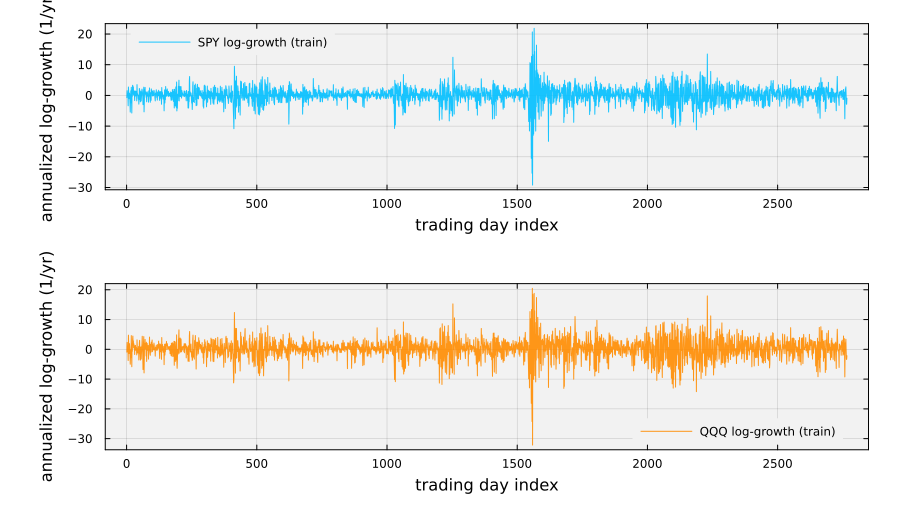

In [4]:
let
    l = @layout [a; b]
    p1 = plot(u_train;
        label = "$(MARKET_TICKER) log-growth (train)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :deepskyblue, alpha = 0.9,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    p2 = plot(Y_train[STUDENT_TICKER];
        label = "$(STUDENT_TICKER) log-growth (train)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :darkorange, alpha = 0.9,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __How co-moving are SPY and `STUDENT_TICKER` in the training window?__ Using only the two time-series above and the simple statistic $\rho(u_\text{train}, Y_\text{train}[\text{STUDENT\_TICKER}])$ (no new code required below; you can compute it inline if you want): (a) does the bulk of the ticker's day-to-day variation line up with SPY's, or are there many large swings in the ticker that SPY does not share? (b) What does that visual co-movement imply about the maximum $\rho$ any observer or baseline can hope to achieve on this ticker using SPY alone as an input?

___

## Task 2: Train the observer zoo
The second task is to build a single HiPPO-LegS filter on SPY (shared across all tickers) and fit one readout row vector per ticker by closed-form ridge regression.

> __Observer zoo.__ We construct one `MySisoLegSHippoModel` at hidden dimension $h$ (set by `H_OBSERVER`) with SPY as the input, so the discretized $(\bar{\mathbf{A}}, \bar{\mathbf{B}})$ are fixed by the LegS theory and do not depend on the target. For every ticker in `TICKER_ZOO` we roll the same hidden-state matrix $\mathbf{X}\in\mathbb{R}^{T\times h}$ forward on SPY and then fit $\bar{\mathbf{C}}_\text{ticker}$ by ridge regression against the ticker's log-growth rate via [`fit_C!`](src/Compute.jl). The full zoo is a `Dict{String, Matrix{Float64}}` keyed by ticker whose values are the $1\times h$ readout rows; it is saved to [`ZOO_PATH`](data) so downstream cells can reload it without retraining. If a cached zoo exists we skip the fit entirely.

The code block below returns the full zoo as `zoo::Dict{String, Matrix{Float64}}` and the shared LegS filter as `market_model::MySisoLegSHippoModel` (with $\bar{\mathbf{C}} = \mathbf{0}$; each ticker's $\bar{\mathbf{C}}$ lives in the `zoo` dictionary).

In [5]:
zoo, market_model = let

    # build the shared LegS filter on SPY (A, B, Ā, B̄ are fixed by construction)
    Random.seed!(42);
    mmodel = build(MySisoLegSHippoModel; h = H_OBSERVER, Δt = Δt)

    # if a cached zoo exists, load it and reuse the readouts; otherwise train fresh
    local z::Dict{String, Matrix{Float64}}
    if isfile(ZOO_PATH)
        (z, hfile, Δtfile) = load_observer_zoo(ZOO_PATH)
        @assert hfile == H_OBSERVER "cached zoo h=$(hfile) does not match H_OBSERVER=$(H_OBSERVER); delete $(ZOO_PATH) to retrain"
        @assert isapprox(Δtfile, Δt) "cached zoo Δt=$(Δtfile) does not match current Δt=$(Δt); delete $(ZOO_PATH) to retrain"
        @info "loaded cached zoo" path=ZOO_PATH n_tickers=length(z) h=hfile
    else
        z = Dict{String, Matrix{Float64}}()
        @info "no cached zoo found; training..." path=ZOO_PATH n_tickers=length(TICKER_ZOO) h=H_OBSERVER
        for t in TICKER_ZOO
            # fresh model per ticker so fit_C! writes into a clean C; only the C row is persisted
            m = build(MySisoLegSHippoModel; h = H_OBSERVER, Δt = Δt)
            fit_C!(m, u_train, Y_train[t]; λ = RIDGE_λ)
            z[t] = copy(m.C)
        end
        save_observer_zoo(ZOO_PATH, z; h = H_OBSERVER, Δt = Δt)
        @info "trained + cached zoo" path=ZOO_PATH n_tickers=length(z) bytes=filesize(ZOO_PATH)
    end

    (z, mmodel)
end;

┌ Info: loaded cached zoo
│   path = /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/data/observer-zoo-N128.jld2
│   n_tickers = 20
│   h = 128
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y146sZmlsZQ==.jl:13


### In-sample fit quality across the zoo
Before picking one ticker, let's tabulate the in-sample reconstruction correlation for every observer in the zoo. This gives us a first look at which tickers are well-explained by SPY's trajectory and which are not.

The code block below returns the in-sample metrics as `zoo_metrics::DataFrame` with one row per ticker.

In [6]:
zoo_metrics = let
    # roll the shared hidden state once on SPY; C varies by ticker but X does not
    X_train, _ = solve(market_model, u_train)
    df = DataFrame(ticker = String[], ρ_in = Float64[], mse_in = Float64[])
    for t in TICKER_ZOO
        yhat = (X_train * zoo[t]')[:, 1]
        push!(df, (t, cor(Y_train[t], yhat), mean((Y_train[t] .- yhat).^2)))
    end
    sort!(df, :ρ_in; rev = true)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

KeyError: KeyError: key "QQQ" not found

### Things to think about
* __Which tickers does SPY explain best, and does that ranking make sense?__ Using only the `zoo_metrics` table above (no new code): (a) which three tickers have the highest in-sample $\rho$, and do they share a common property (sector, market cap, index weight)? (b) Which three are hardest for SPY alone to explain, and what does that tell you about the limits of a single-market-factor observer? Put the two observations together: does the ranking line up with what you would predict from single-index-model intuition (names with larger SPY-correlation should be better explained)?

___

## Task 3: Evaluate the observer and compare to static and rolling SIM baselines
The third task applies the trained observer for `STUDENT_TICKER` to the 2025 holdout and benchmarks it against two single-index-model (SIM) baselines: a static $(\alpha, \beta)$ fit once on 2014-2024 and then frozen, and a rolling-window OLS fit that re-estimates itself every day.

**Observer.** In-sample we apply the trained readout $\bar{\mathbf{C}}$ to the hidden state rolled out on the training SPY series. Out-of-sample we apply the same readout to the hidden state rolled out on the 2025 SPY series, dropping the first `WARMUP_STEPS` samples via [`predict`](src/Compute.jl) so the zero initial state is forgotten before we compare. The readout is frozen at its Task 2 value throughout; the observer never sees 2025 data during evaluation.

**Static SIM.** We fit a single intercept-slope pair on the full training pair by ordinary least squares,

$$y_t \;=\; \alpha \;+\; \beta\, u_t \;+\; \varepsilon_t,$$

and then freeze $(\hat{\alpha}, \hat{\beta})$ for the rest of the evaluation. This matches the observer's training discipline exactly, one fit on 2014-2024 and no re-adaptation in 2025, but with zero memory of SPY's trajectory beyond its current value. Implemented as [`static_alpha_beta`](src/Compute.jl).

**Rolling SIM.** At every day $t$ we refit the same regression on the trailing $W$ = `BETA_WINDOW` days and predict $\hat{y}_t = \hat{\alpha}_t + \hat{\beta}_t\, u_t$, where the window OLS solution is

$$\hat{\beta}_t \;=\; \frac{\sum_{\tau = t - W}^{t - 1} (u_\tau - \bar{u}_t)(y_\tau - \bar{y}_t)}{\sum_{\tau = t - W}^{t - 1} (u_\tau - \bar{u}_t)^2}, \qquad \hat{\alpha}_t \;=\; \bar{y}_t - \hat{\beta}_t\,\bar{u}_t.$$

The intercept is left free (this is SIM, not CAPM, which would pin $\alpha = 0$ on excess returns). Implemented as [`rolling_beta`](src/Compute.jl).

**Caveat.** Observer and static SIM are both frozen after training, so their 2025 predictions are true out-of-sample extrapolations. Rolling SIM refits daily on trailing 2025 data, so it is continuously adapting to the new regime. Read the comparison accordingly: observer versus static SIM is the clean apples-to-apples test of what the LegS memory adds over a single $(\alpha, \beta)$, while observer versus rolling SIM is a harder stress test against an adaptive benchmark.

The code block below stores the observer outputs as `ŷ_in::Vector{Float64}` and `ŷ_oos::Vector{Float64}`, the rolling-SIM predictions as `β_in::Vector{Float64}` and `β_oos::Vector{Float64}`, and the static-SIM predictions as `ŝ_in::Vector{Float64}` and `ŝ_oos::Vector{Float64}`.

In [7]:
(; ŷ_in, ŷ_oos, β_in, β_oos, ŝ_in, ŝ_oos) = let
    @info "evaluating observer" ticker=STUDENT_TICKER h=H_OBSERVER

    # --- observer: install the student's trained C into the shared market_model
    m = deepcopy(market_model)
    m.C = copy(zoo[STUDENT_TICKER])

    # --- in-sample observer
    (_, yhat_in) = solve(m, u_train)

    # --- out-of-sample observer (drop first WARMUP_STEPS samples)
    (_, yhat_oos) = predict(m, u_test; warmup = WARMUP_STEPS)

    # --- rolling-SIM baseline: refits (α_t, β_t) every day on the trailing BETA_WINDOW days
    (_, _, bhat_in)  = rolling_beta(u_train, Y_train[STUDENT_TICKER]; window = BETA_WINDOW)
    (_, _, bhat_oos) = rolling_beta(u_test,  Y_test[STUDENT_TICKER];  window = BETA_WINDOW)

    # --- static-SIM baseline: fit (α, β) once on 2014-2024, freeze for 2025
    (α_s, β_s) = static_alpha_beta(u_train, Y_train[STUDENT_TICKER])
    shat_in  = α_s .+ β_s .* u_train
    shat_oos = α_s .+ β_s .* u_test
    @info "static-SIM fit" α=round(α_s, digits=4) β=round(β_s, digits=4)

    @info "in-sample correlations" ρ_obs=round(cor(Y_train[STUDENT_TICKER], yhat_in), digits=4) ρ_roll=round(cor(filter(!isnan, bhat_in), Y_train[STUDENT_TICKER][BETA_WINDOW+1:end]), digits=4) ρ_stat=round(cor(Y_train[STUDENT_TICKER], shat_in), digits=4)
    (ŷ_in = yhat_in, ŷ_oos = yhat_oos, β_in = bhat_in, β_oos = bhat_oos, ŝ_in = shat_in, ŝ_oos = shat_oos)
end;

┌ Info: evaluating observer
│   ticker = QQQ
│   h = 128
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-14/L14b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y154sZmlsZQ==.jl:2


KeyError: KeyError: key "QQQ" not found

### In-sample fit: observer, static SIM, and rolling SIM
Two panels: the full in-sample time series with all four curves (observed truth plus the three models) overlaid, and a scatter of observer predictions against truth showing how tight the fit is.

In [8]:
let
    l = @layout [a b]
    p1 = plot(Y_train[STUDENT_TICKER];
        label = "observed $(STUDENT_TICKER)",
        xlabel = "trading day index", ylabel = "annualized log-growth (1/yr)",
        lw = 1.0, c = :deepskyblue, alpha = 0.75,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, ŷ_in;  label = "observer $(STUDENT_TICKER)", lw = 1.0, c = :red,    alpha = 0.9)
    plot!(p1, ŝ_in;  label = "static SIM",                 lw = 1.0, c = :green4, alpha = 0.7, ls = :dot)
    plot!(p1, β_in;  label = "rolling SIM",                lw = 1.0, c = :gray40, alpha = 0.6, ls = :dash)

    p2 = scatter(Y_train[STUDENT_TICKER], ŷ_in;
        label = "observer", xlabel = "observed", ylabel = "predicted",
        c = :white, msc = :red, markersize = 2,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Y_train[STUDENT_TICKER], Y_train[STUDENT_TICKER];
        label = "", c = :black, lw = 1, ls = :dash)

    plot(p1, p2; layout = l, size = (900, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

UndefVarError: UndefVarError: `ŷ_in` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Out-of-sample fit: observer, static SIM, and rolling SIM
Same overlay on the 2025 holdout. The observer and the static-SIM baseline were both fit once on 2014-2024 and then frozen, so they are directly comparable; the rolling-SIM baseline gets to re-adapt daily on trailing 2025 data and serves as a stress test.

In [9]:
let
    l = @layout [a b]
    y_te    = Y_test[STUDENT_TICKER][(WARMUP_STEPS + 1):end]   # observer target, warmup-trimmed
    β_te    = β_oos[(WARMUP_STEPS + 1):end]                    # rolling-SIM prediction, aligned
    s_te    = ŝ_oos[(WARMUP_STEPS + 1):end]                    # static-SIM prediction, aligned
    t_axis  = (WARMUP_STEPS + 1):length(Y_test[STUDENT_TICKER])

    p1 = plot(t_axis, y_te;
        label = "observed $(STUDENT_TICKER) (2025)",
        xlabel = "trading day index (2025, post-warmup)", ylabel = "annualized log-growth (1/yr)",
        lw = 1.2, c = :deepskyblue, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, t_axis, ŷ_oos;  label = "observer",    lw = 1.2, c = :red,    alpha = 0.9)
    plot!(p1, t_axis, s_te;   label = "static SIM",  lw = 1.2, c = :green4, alpha = 0.7, ls = :dot)
    plot!(p1, t_axis, β_te;   label = "rolling SIM", lw = 1.2, c = :gray40, alpha = 0.6, ls = :dash)

    # metrics table, ignoring any NaNs in the rolling baseline from points before one full window
    mask    = .!isnan.(β_te)
    ρ_obs   = cor(y_te, ŷ_oos)
    ρ_stat  = cor(y_te, s_te)
    ρ_roll  = cor(y_te[mask], β_te[mask])
    mse_obs  = mean((y_te .- ŷ_oos).^2)
    mse_stat = mean((y_te .- s_te).^2)
    mse_roll = mean((y_te[mask] .- β_te[mask]).^2)
    summary = DataFrame(
        model   = ["observer (h = $(H_OBSERVER))", "static SIM (frozen)", "rolling SIM (W = $(BETA_WINDOW))"],
        ρ_oos   = [ρ_obs,   ρ_stat,  ρ_roll],
        mse_oos = [mse_obs, mse_stat, mse_roll])
    pretty_table(summary; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])

    p2 = density(y_te; label = "observed $(STUDENT_TICKER) (2025)",
        lw = 2, c = :deepskyblue,
        xlabel = "annualized log-growth (1/yr)", ylabel = "density",
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    density!(p2, ŷ_oos;    label = "observer",    lw = 2, c = :red)
    density!(p2, s_te;     label = "static SIM",  lw = 2, c = :green4, ls = :dot)
    density!(p2, β_te[mask]; label = "rolling SIM", lw = 2, c = :gray40, ls = :dash)

    plot(p1, p2; layout = l, size = (900, 460),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

UndefVarError: UndefVarError: `β_oos` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Things to think about
* __What does the extra memory buy you?__ Using the metrics table above, does the observer meaningfully beat the frozen static-SIM baseline (the clean ablation) on the 2025 holdout, and does it tie or beat the rolling-SIM baseline as well? If all three are nearly indistinguishable, what does that suggest about whether daily returns for this ticker actually depend on SPY's trajectory beyond its current value?

___

## Summary
This notebook used a single HiPPO-LegS filter on SPY as a market observer and fit a zoo of ticker-specific readouts (one per entry of `TICKER_ZOO`) by closed-form ridge regression, extending the static single index model (SIM) into a memory-aware linear factor model. We saved the zoo to disk once, then picked one ticker and compared the observer's in-sample and out-of-sample projections to two baselines using the same SPY input: a static $(\alpha, \beta)$ fit once on 2014-2024 and then frozen, and a rolling-window OLS SIM that refits daily.

> __Key Takeaways:__
>
> * **The observer zoo is cheap to persist and explore:** Because the LegS state and input matrices are shared across all tickers, only the per-ticker readout row vector needs to be stored, so the full zoo fits in well under a megabyte and a student can swap `STUDENT_TICKER` and rerun Task 3 without retraining anything.
> * **Static SIM is the clean ablation of the observer:** Because both are fit once on 2014-2024 and then frozen, the observer-minus-static-SIM gap on the 2025 holdout isolates what the `H_OBSERVER` polynomial coefficients of SPY's recent trajectory add over a single $(\alpha, \beta)$ pair, with no re-adaptation confounding the comparison.
> * **Memory helps most when SPY's trajectory carries signal beyond its current value:** For tickers that are almost entirely explained by contemporaneous market moves, the observer ties the static-SIM baseline; the observer's advantage grows on tickers whose co-movement with SPY has persistent lagged structure, which is also where the rolling-SIM baseline struggles despite its daily re-adaptation.

A natural follow-up experiment: swap the target from daily returns to realized volatility, short-term momentum, or lead-lag structure in less-liquid names, since those targets genuinely depend on SPY's recent trajectory beyond its current value and should let the LegS memory start to pay off over a single-$\beta$ fit.

___